# Description

Prove that the Noise Reduction model works on a 2D polinomial.

Add libs folder path to system variables in order to make the importation of local libraries easier.

In [356]:
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(CURRENT_DIR)
sys.path.append(LIBS_PATH)
print(CURRENT_DIR)

/home/jjavier98/S-noise-gradient


Import external and local libraries

In [357]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from tqdm import tqdm
import math
from typing import List

# Locals
from src.libs.xai_benchmark import XAIBenchmark
from src.libs.utils import *
from src.libs.dataset import TensorDataset
from src.libs.models import *
import src.libs.config as cfg
from src.libs.dlnr import DLNoiseReduction

Global / Path variables

In [358]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

Make sure that the GPU is being used

In [359]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

Functions definition

In [360]:
def polinomial_function(x:float):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6


def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df


def add_uniform_noise(df:pd.DataFrame, columns:List[str], low:float = 0.0, high:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.uniform(low, high, size=len(df))
    return df

Generate 2D data with normal distribution at the points indicated in ‘means’ variable.  
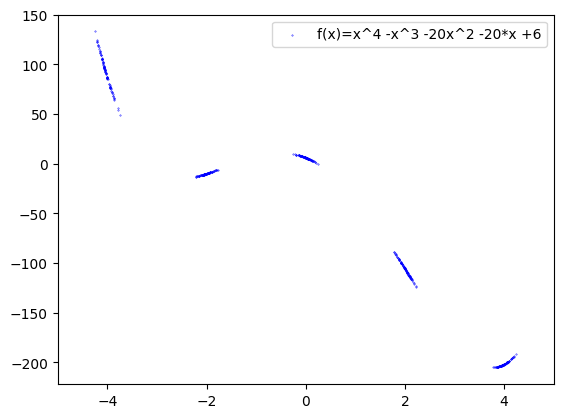

In [361]:
# means = [-4, -2, 0, 2, 4]
# X_train = [np.random.normal(loc=m, scale=0.1, size=(100)) for m in means]
# X_train = np.concatenate(X_train, axis=0)
# y_train = polinomial_function(X_train)

# df_train = pd.DataFrame({'X': X_train, 'y': y_train})

Generate continious 2D data like so  
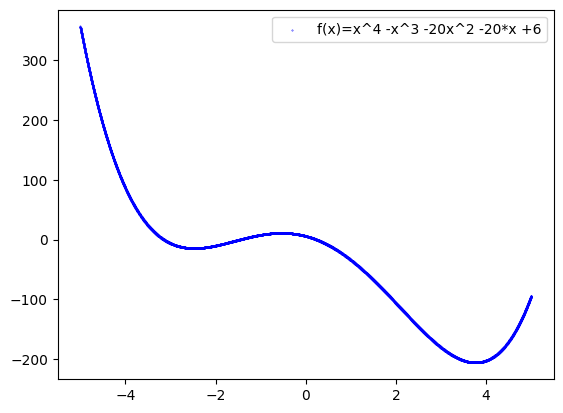

In [362]:
X = np.linspace(-5, 5, 5000)
y = polinomial_function(X)

df_data = pd.DataFrame({'X': X, 'y': y})
scaler = MinMaxScaler()
df_data = pd.DataFrame(scaler.fit_transform(df_data), columns=['X', 'y'])

In [363]:
X_train, X_test, y_train, y_test = train_test_split(
    df_data['X'].values, df_data['y'].values, test_size=0.2, random_state=42
)

# No noise XAI Benchmarck

In [364]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 1},
    'tree': {"max_depth": 5},
    'svm': {"kernel": 'poly', "degree": 2},
    'knn': {"n_neighbors": 5, "weights": 'uniform', "algorithm": 'auto', "leaf_size": 30, "p": 2, "n_jobs": None},
}
xai_benchmark = XAIBenchmark(is_ts = False, model_params = model_params)

In [365]:
xai_benchmark.fit(X_train.reshape(-1,1), y_train)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Regressor model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [366]:
xai_benchmark.predict(X_test.reshape(-1,1), y_test, get_metrics=True)

Calculating metrics for ridge model...
Calculating metrics for pls model...
Calculating metrics for decision_tree model...
Calculating metrics for svm model...
Calculating metrics for knn model...
Calculating metrics for arima model...


({'ridge': array([ 4.25496948e-01,  2.90654237e-01,  2.82327545e-01,  4.80925380e-01,
          5.24423029e-01,  5.98866147e-01,  5.38839392e-01,  3.05319159e-01,
          3.12154504e-01,  4.13193327e-01,  3.05816275e-01,  5.83704110e-01,
          4.98324439e-01,  5.13362198e-01,  2.36592874e-01,  1.71719238e-01,
          4.78688358e-01,  1.95580806e-01,  3.95297152e-01,  4.77321289e-01,
          4.96957371e-01,  2.33113062e-01,  4.73220082e-01,  5.32252605e-01,
          1.96017474e-02,  5.49775944e-01,  1.06721323e-01,  5.70654815e-01,
          2.99169040e-02,  5.51640129e-01,  3.68204331e-01,  5.63198075e-01,
          1.02808227e-02,  7.29812676e-03,  3.93930083e-01,  2.99478046e-01,
          1.66499520e-01,  7.57758535e-02, -5.12977283e-03,  3.51178108e-01,
          1.64759615e-01,  9.98859787e-02,  6.08435630e-01,  6.03961586e-01,
          5.07893922e-01,  1.26605963e-01,  1.43135069e-01,  3.60065748e-02,
          2.19193815e-01,  2.81581871e-01,  3.84921547e-02,  3.6876

Add goussian noise to the dataframe

In [401]:
sigma = 0.05
# df_noisy = add_gaussian_noise(
#     df=df_data.copy(),
#     columns=[x for x in df_data.columns],
#     mean=0.0,
#     std=sigma
# )
df_noisy = add_uniform_noise(
    df=df_data.copy(),
    columns=[x for x in df_data.columns],
    low=-0.1,
    high=0.1
)

Plot the new noisy data

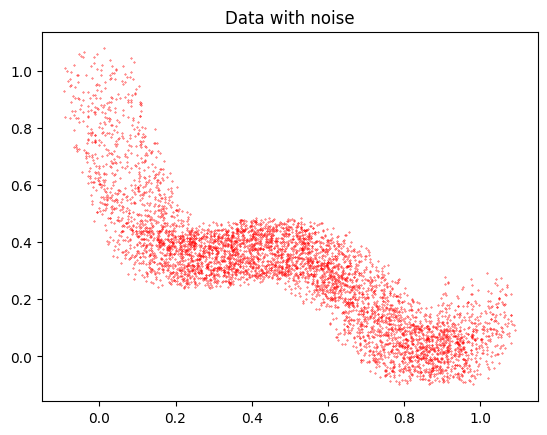

In [402]:
plt.title('Data with noise')
plt.scatter(df_noisy['X'], df_noisy['y'], color='r', s=0.1)

In [403]:
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(
    df_noisy['X'].values, df_noisy['y'].values, test_size=0.2, random_state=42
)

# Noisy XAI Benchmarck

In [404]:
xai_benchmark.fit(X_train_noisy.reshape(-1,1), y_train_noisy)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Regressor model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [405]:
prediction, metrics = xai_benchmark.predict(X_test_noisy.reshape(-1,1), y_test, get_metrics=True)
metrics

Calculating metrics for ridge model...
Calculating metrics for pls model...
Calculating metrics for decision_tree model...
Calculating metrics for svm model...
Calculating metrics for knn model...
Calculating metrics for arima model...


{'ridge': {'mse': 0.010669882655061507,
  'rmse': 0.10329512406237532,
  'mae': 0.08027670686405827,
  'mape': 208.39188653036058,
  'R2': 0.7540861067789242},
 'pls': {'mse': 0.010670203944850812,
  'rmse': 0.10329667925374374,
  'mae': 0.08031937706518741,
  'mape': 206.74562289301545,
  'R2': 0.7540787018593488},
 'decision_tree': {'mse': 0.007049951093376615,
  'rmse': 0.08396398688352415,
  'mae': 0.05534125631274798,
  'mape': 101.91842640874744,
  'R2': 0.8375164023413124},
 'svm': {'mse': 0.01552906149630959,
  'rmse': 0.12461565510123353,
  'mae': 0.08351862738981132,
  'mape': 196.29111459114233,
  'R2': 0.6420942859371135},
 'knn': {'mse': 0.008586256488209865,
  'rmse': 0.09266205527728093,
  'mae': 0.06309229365276975,
  'mape': 111.12710625759046,
  'R2': 0.8021084364776232},
 'arima': {'mse': None, 'rmse': None, 'mae': None, 'mape': None, 'R2': None}}

Create Datasets for DataLoaders

In [406]:
# Transform the data into a tensor
train_dataset = TensorDataset(
    x=X_train_noisy.reshape(-1,1),
    y=y_train_noisy.reshape(-1,1)
)
# Transform the data into a tensor
val_dataset = TensorDataset(
    x=X_test_noisy.reshape(-1,1),
    y=y_test_noisy.reshape(-1,1)
)

# Create the dataloaders
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

Create Neural Network model

In [427]:
model = GridFullyDenseNN(
    n_layers=4,
    hidden_layers=[
        (1, 1024),
        (1024, 512),
        (512, 1024),
        (1024, 1),
    ],
    dropout_layers=[
        0.0,
        0.0,
        0.0,
        0.0,
    ],
    activation_func_layers=[
        nn.Sigmoid(),
        nn.Sigmoid(),
        nn.Sigmoid(),
        nn.Sigmoid(),
    ],
    want_dropout=[
        False,
        False,
        False,
        False,
    ],
    want_linear=[
        True,
        True,
        True,
        True,
    ],
    want_activation=[
        True,
        True,
        True,
        True,
    ],
)
model.to(device)

GridFullyDenseNN(
  (model): Sequential(
    (linear_0): Linear(in_features=1, out_features=1024, bias=True)
    (activation_0): Sigmoid()
    (linear_1): Linear(in_features=1024, out_features=512, bias=True)
    (activation_1): Sigmoid()
    (linear_2): Linear(in_features=512, out_features=1024, bias=True)
    (activation_2): Sigmoid()
    (linear_3): Linear(in_features=1024, out_features=1, bias=True)
    (activation_3): Sigmoid()
  )
)

Set model parameters and create the model Trainer object

In [428]:
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=model,
    train_generator=train_dataloader,
    val_generator=val_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=15,
    epochs=500,
    checkpoints_path=os.path.join(CHECKPOINT_PATH, f'model_noise_{sigma}_polinomial')
)

Train the model

In [429]:
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)

Training is started!


Epochs loop:  19%|█▉        | 96/500 [00:36<02:31,  2.66epoch/s, Train loss: 0.0094]                   


Training stopped as validation loss did not improve for 15 epochs.


or load a checkpoint

In [430]:
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, f'model_noise_{sigma}_polinomial.pth')))

Predict over the datasets

In [431]:
y_pred_test = model(torch.tensor(X_test_noisy.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [432]:
y_pred_total = model(torch.tensor(df_noisy['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

Show the metrics

In [433]:
gt_values = y_test_noisy
predicted_values = y_pred_test

In [434]:
mae = mean_absolute_error(gt_values, predicted_values)
mse = mean_squared_error(gt_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs(gt_values - predicted_values) / gt_values) * 100
r_squared = r2_score(gt_values, predicted_values)
print("MAE: ", mae)
print("MAPE: ", mape)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R-squared: ", r_squared)

MAE:  0.07697671575446514
MAPE:  30.128052367711327
MSE:  0.009828931181109621
RMSE:  0.09914096621028878
R-squared:  0.7857783577954054


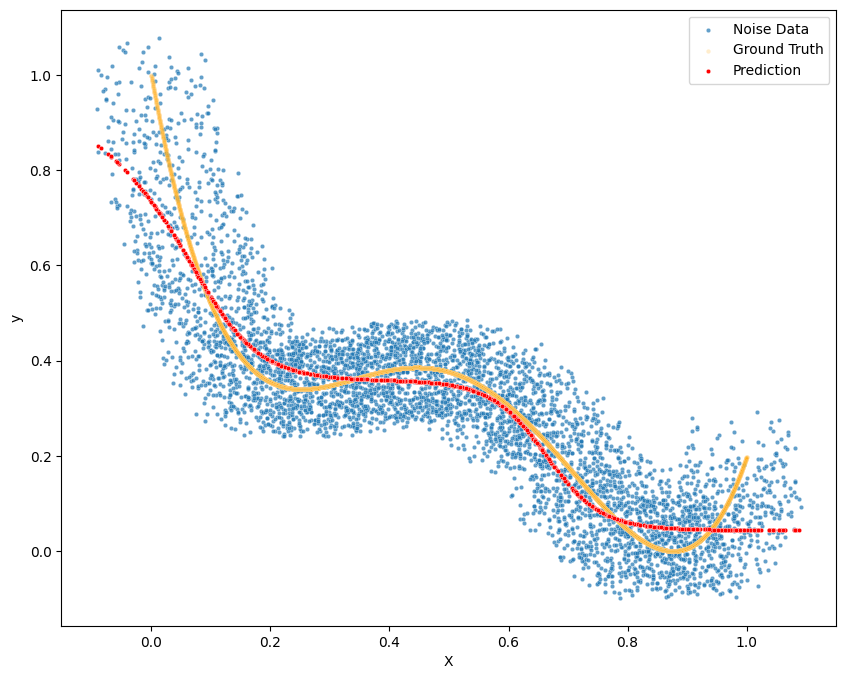

In [435]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.scatterplot(x=df_noisy['X'].values, y=df_noisy['y'].values, label='Noise Data', s=10, alpha=0.7)
sns.scatterplot(x=df_data['X'], y=df_data['y'], label='Ground Truth', s=10, alpha=0.2, color='orange')
sns.scatterplot(x=X_test_noisy, y=y_pred_test, label='Prediction', s=10, color='r')
plt.legend()
plt.show()

# Gradients to reduce noise

In [436]:
df_no_noise = df_noisy.copy()
dlnr = DLNoiseReduction(model=model, criterion=criterion)
dlnr.fit(df_noisy['X'].values.reshape(-1, 1), df_noisy['y'].values.reshape(-1, 1))

 78%|███████▊  | 155/200 [00:38<00:11,  3.98it/s]


Noise threshold reached in all data points at epoch:  155


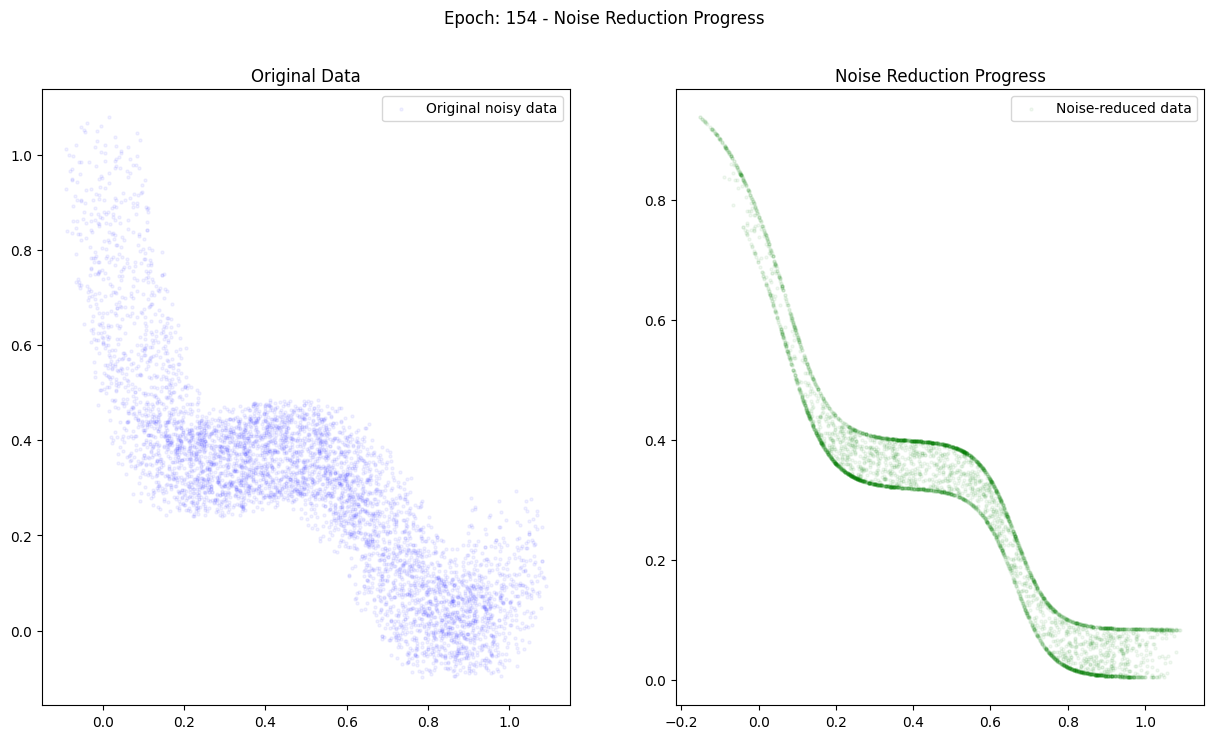

In [437]:
df_no_noise['X'], df_no_noise['y'], x_grad, y_grad = dlnr.transform(
    nrr=0.05,
    nr_threshold=0.04,
    max_epochs=200,
    plot_progress=True,
    path_to_save_imgs=None
)

In [438]:
sigma = 0.01
df_prediction = pd.DataFrame({
    'X': df_noisy['X'].values,
    'y': y_pred_total
})
df_prediction = add_gaussian_noise(
    df=df_prediction.copy(),
    columns=['y'],
    mean=0.0,
    std=sigma
)

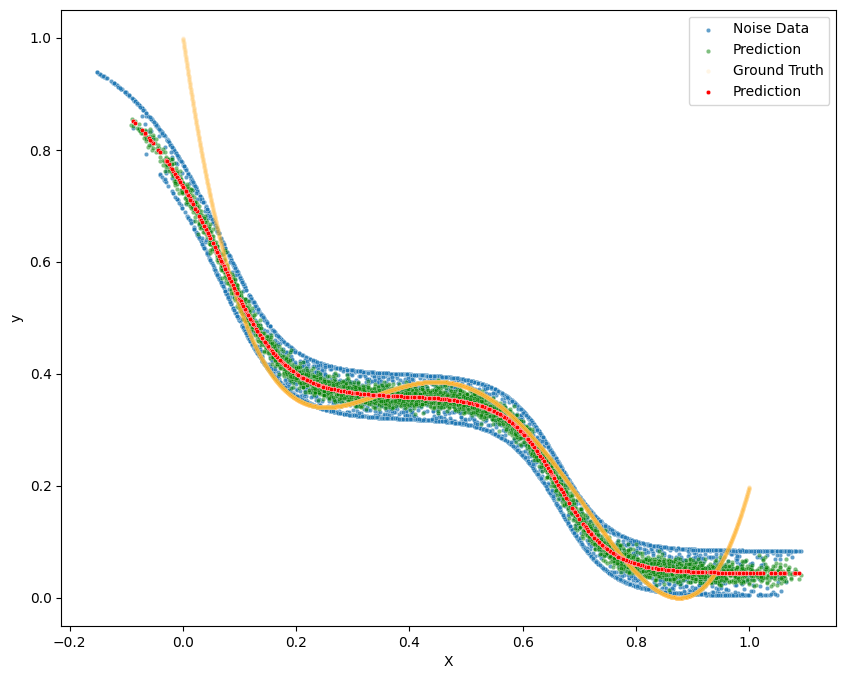

In [439]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.scatterplot(x=df_no_noise['X'].values, y=df_no_noise['y'].values, label='Noise Data', s=10, alpha=0.7)
sns.scatterplot(x=df_prediction['X'], y=df_prediction['y'], label='Prediction', s=10, color='g', alpha=0.5)
sns.scatterplot(x=df_data['X'], y=df_data['y'], label='Ground Truth', s=10, alpha=0.1, color='orange')
sns.scatterplot(x=X_test_noisy, y=y_pred_test, label='Prediction', s=10, color='r')
plt.legend()
plt.show()

# Denoised XAI Benchmark

In [440]:
xai_benchmark_denoised = XAIBenchmark(is_ts = False, model_params = model_params)
# xai_benchmark_denoised.fit(df_no_noise['X'].values.reshape(-1,1), df_no_noise['y'].values)
xai_benchmark_denoised.fit(df_prediction['X'].values.reshape(-1,1), df_prediction['y'].values)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Regressor model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [441]:
prediction, metrics = xai_benchmark_denoised.predict(df_no_noise['X'].values.reshape(-1,1), df_no_noise['y'].values.reshape(-1,1), get_metrics=True)
metrics

Calculating metrics for ridge model...
Calculating metrics for pls model...
Calculating metrics for decision_tree model...
Calculating metrics for svm model...
Calculating metrics for knn model...
Calculating metrics for arima model...


{'ridge': {'mse': 0.005952106925732213,
  'rmse': 0.07714989906495155,
  'mae': 0.06196558425473444,
  'mape': 0.7021734237246152,
  'R2': 0.8504188039972584},
 'pls': {'mse': 0.0059503856035236,
  'rmse': 0.07713874255861058,
  'mae': 0.06198588597639264,
  'mape': 0.6986335904213127,
  'R2': 0.8504620621977382},
 'decision_tree': {'mse': 0.0013276437016072548,
  'rmse': 0.036436845384956895,
  'mae': 0.03356273461630233,
  'mape': 0.5449558241082199,
  'R2': 0.9666352545023391},
 'svm': {'mse': 0.011356461437147055,
  'rmse': 0.1065666994757136,
  'mae': 0.08048611001969937,
  'mape': 0.9672299951758964,
  'R2': 0.7146030631970716},
 'knn': {'mse': 0.0012696519090654413,
  'rmse': 0.03563217519413376,
  'mae': 0.03342397656001004,
  'mape': 0.5448818245095853,
  'R2': 0.9680926345183543},
 'arima': {'mse': None, 'rmse': None, 'mae': None, 'mape': None, 'R2': None}}

In [442]:
prediction, metrics = xai_benchmark_denoised.predict(df_data['X'].values.reshape(-1,1), df_data['y'].values, get_metrics=True)
metrics

Calculating metrics for ridge model...
Calculating metrics for pls model...
Calculating metrics for decision_tree model...
Calculating metrics for svm model...
Calculating metrics for knn model...
Calculating metrics for arima model...


{'ridge': {'mse': 0.00876393213964372,
  'rmse': 0.09361587546801942,
  'mae': 0.07355128031424879,
  'mape': 58359986996.9476,
  'R2': 0.7869882114430957},
 'pls': {'mse': 0.008761653131731507,
  'rmse': 0.09360370255353956,
  'mae': 0.073563605744748,
  'mape': 57882789169.97354,
  'R2': 0.7870436038792512},
 'decision_tree': {'mse': 0.0025915514993287403,
  'rmse': 0.05090728336229248,
  'mae': 0.034870966323093146,
  'mape': 43016090226.77726,
  'R2': 0.9370110344063226},
 'svm': {'mse': 0.0127426025640264,
  'rmse': 0.11288313675667593,
  'mae': 0.08128487630559642,
  'mape': 65138952137.98145,
  'R2': 0.6902846211285928},
 'knn': {'mse': 0.0025547100812037854,
  'rmse': 0.05054413992941007,
  'mae': 0.035071856519604094,
  'mape': 48446621481.87395,
  'R2': 0.9379064836456281},
 'arima': {'mse': None, 'rmse': None, 'mae': None, 'mape': None, 'R2': None}}

In [443]:
prediction, metrics = xai_benchmark_denoised.predict(X_test_noisy.reshape(-1,1), y_test_noisy, get_metrics=True)
metrics

Calculating metrics for ridge model...
Calculating metrics for pls model...
Calculating metrics for decision_tree model...
Calculating metrics for svm model...
Calculating metrics for knn model...
Calculating metrics for arima model...


{'ridge': {'mse': 0.014150018302036564,
  'rmse': 0.118953849462876,
  'mae': 0.09426943609277759,
  'mape': 1.0693795137592677,
  'R2': 0.6916002256976699},
 'pls': {'mse': 0.014155921458450049,
  'rmse': 0.11897865967664138,
  'mae': 0.0943283184882452,
  'mape': 1.066274613727866,
  'R2': 0.6914715663513191},
 'decision_tree': {'mse': 0.009806033787863454,
  'rmse': 0.09902541990753412,
  'mae': 0.07689132751778192,
  'mape': 0.8242564949136839,
  'R2': 0.7862774066841416},
 'svm': {'mse': 0.018658490251235036,
  'rmse': 0.1365960843188231,
  'mae': 0.10444787489155351,
  'mape': 1.3246241286280416,
  'R2': 0.5933380396069933},
 'knn': {'mse': 0.009842111373522153,
  'rmse': 0.09920741591999135,
  'mae': 0.0769514263829218,
  'mape': 0.8126227806817637,
  'R2': 0.7854910953849602},
 'arima': {'mse': None, 'rmse': None, 'mae': None, 'mape': None, 'R2': None}}

In [ ]:
{'ridge': {'mse': 0.010669882655061507,
  'rmse': 0.10329512406237532,
  'mae': 0.08027670686405827,
  'mape': 208.39188653036058,
  'R2': 0.7540861067789242},
 'pls': {'mse': 0.010670203944850812,
  'rmse': 0.10329667925374374,
  'mae': 0.08031937706518741,
  'mape': 206.74562289301545,
  'R2': 0.7540787018593488},
 'decision_tree': {'mse': 0.007049951093376615,
  'rmse': 0.08396398688352415,
  'mae': 0.05534125631274798,
  'mape': 101.91842640874744,
  'R2': 0.8375164023413124},
 'svm': {'mse': 0.01552906149630959,
  'rmse': 0.12461565510123353,
  'mae': 0.08351862738981132,
  'mape': 196.29111459114233,
  'R2': 0.6420942859371135},
 'knn': {'mse': 0.008586256488209865,
  'rmse': 0.09266205527728093,
  'mae': 0.06309229365276975,
  'mape': 111.12710625759046,
  'R2': 0.8021084364776232},
 'arima': {'mse': None, 'rmse': None, 'mae': None, 'mape': None, 'R2': None}}

{'ridge': {'mse': 0.010266909745367432,
  'rmse': 0.10132576052202831,
  'mae': 0.0790839181443842,
  'mape': 260.5691871380228,
  'R2': 0.7633736163316639},
 'pls': {'mse': 0.010264324892367806,
  'rmse': 0.10131300455700544,
  'mae': 0.079115887124807,
  'mape': 259.06013708585334,
  'R2': 0.7634331906761147},
 'decision_tree': {'mse': 0.005372723962380028,
  'rmse': 0.07329886740175477,
  'mae': 0.04669932599758234,
  'mape': 79.4778889214492,
  'R2': 0.876172258917554},
 'svm': {'mse': 0.014923270113082832,
  'rmse': 0.1221608370677069,
  'mae': 0.0827044505121673,
  'mape': 269.6561619601843,
  'R2': 0.6560562499385081},
 'knn': {'mse': 0.0059972737364886635,
  'rmse': 0.07744206696937178,
  'mae': 0.051272070411874336,
  'mape': 51.87705986768222,
  'R2': 0.8617779613018683},
 'arima': {'mse': None, 'rmse': None, 'mae': None, 'mape': None, 'R2': None}}

In [444]:
prediction, metrics = xai_benchmark.predict(df_no_noise['X'].values.reshape(-1,1), df_no_noise['y'].values.reshape(-1,1), get_metrics=True)
metrics

Calculating metrics for ridge model...
Calculating metrics for pls model...
Calculating metrics for decision_tree model...
Calculating metrics for svm model...
Calculating metrics for knn model...
Calculating metrics for arima model...


{'ridge': {'mse': 0.005989819764791463,
  'rmse': 0.0773939258908053,
  'mae': 0.06224517162917907,
  'mape': 0.7916121126832134,
  'R2': 0.8494710502620637},
 'pls': {'mse': 0.005983415052769085,
  'rmse': 0.0773525374681987,
  'mae': 0.06224763526599041,
  'mape': 0.7859345058266833,
  'R2': 0.8496320057852615},
 'decision_tree': {'mse': 0.001712121974208348,
  'rmse': 0.0413777956663758,
  'mae': 0.03433890240545435,
  'mape': 0.5547688077308381,
  'R2': 0.9569730087513247},
 'svm': {'mse': 0.011126019432139339,
  'rmse': 0.10547994800974894,
  'mae': 0.07095556475289225,
  'mape': 0.8600083068898297,
  'R2': 0.7203942546438017},
 'knn': {'mse': 0.0028402438898622977,
  'rmse': 0.053293938584629844,
  'mae': 0.04139560546729341,
  'mape': 0.5912386380291433,
  'R2': 0.9286224049254932},
 'arima': {'mse': None, 'rmse': None, 'mae': None, 'mape': None, 'R2': None}}